# Final Results and Analysis

This notebook consolidates the final results from the earthquake detection and P-wave picking experiments.

Stage 1 evaluates earthquake detection using STA/LTA, Random Forest, and 1D CNN.

Stage 2 evaluates P-wave arrival-time picking using STA/LTA, 1D CNN, and 1D U-Net.

All result files are loaded from the repository `results/` directory using paths relative to this notebook.


## Imports and paths

Previously generated result files are loaded for final comparison and visualization.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("../results")
metrics_dir = results_dir / "metrics"
figures_dir = results_dir / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

print("Metrics directory:", metrics_dir)
print("Figures directory:", figures_dir)


Metrics directory: ../results/metrics
Figures directory: ../results/figures


## Separate Stage 1 and Stage 2 results

The consolidated results are separated by task for independent analysis.


In [4]:
final_results = pd.read_csv(
    metrics_dir / "final_project_results.csv"
)

stage1_results = final_results[
    final_results["Stage"] == "Stage 1"
].copy()

stage2_results = final_results[
    final_results["Stage"] == "Stage 2"
].copy()

print("Stage 1 results")
display(stage1_results)

print("Stage 2 results")
display(stage2_results)


Stage 1 results


,Stage,Task,Model,Accuracy,Precision,Recall,F1,MAE_s,Median_error_s,Within_0.5s_pct,Within_1.0s_pct,Within_2.0s_pct
0,Stage 1,Earthquake Detection,STA/LTA,0.6977,0.9859,0.6798,0.8047,NaN,NaN,NaN,NaN,NaN
1,Stage 1,Earthquake Detection,Random Forest,0.9599,0.9752,0.9812,0.9782,NaN,NaN,NaN,NaN,NaN
2,Stage 1,Earthquake Detection,1D CNN,0.9304,0.9388,0.9885,0.9630,NaN,NaN,NaN,NaN,NaN


Stage 2 results


,Stage,Task,Model,Accuracy,Precision,Recall,F1,MAE_s,Median_error_s,Within_0.5s_pct,Within_1.0s_pct,Within_2.0s_pct
3,Stage 2,P-wave Picking,STA/LTA,NaN,NaN,NaN,NaN,2.7246,0.25,63.42,72.15,76.42
4,Stage 2,P-wave Picking,1D CNN,NaN,NaN,NaN,NaN,4.9452,0.11,82.02,83.96,84.99
5,Stage 2,P-wave Picking,1D U-Net,NaN,NaN,NaN,NaN,3.8543,0.10,78.49,83.29,85.18


## Stage 1 earthquake detection performance

F1 score is compared across the three earthquake detection methods using the held-out test set.


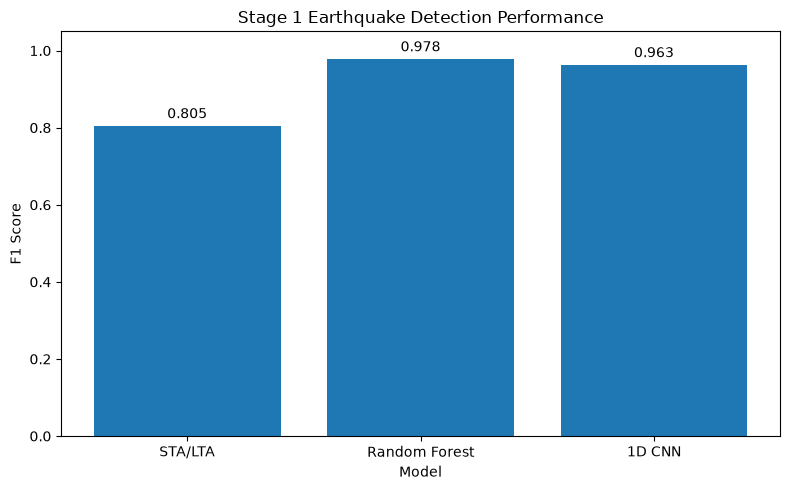

Saved: ../results/figures/stage1_f1_comparison.png


In [5]:
plt.figure(figsize=(8, 5))

models = stage1_results["Model"]
f1_scores = stage1_results["F1"]

bars = plt.bar(models, f1_scores)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Stage 1 Earthquake Detection Performance")
plt.ylim(0, 1.05)

for bar, value in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

stage1_figure_path = figures_dir / "stage1_f1_comparison.png"
plt.savefig(stage1_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {stage1_figure_path}")


## Stage 2 P-wave picking performance

Tolerance-based timing accuracy is compared across STA/LTA, the baseline 1D CNN, and the 1D U-Net.

A pick is considered successful for a given tolerance when its absolute timing error is less than or equal to that tolerance.


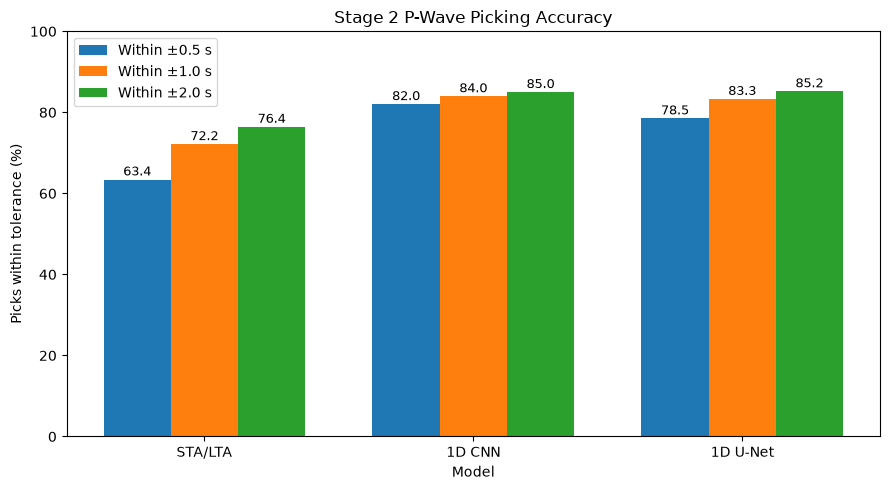

Saved: ../results/figures/stage2_tolerance_comparison.png


In [6]:
tolerance_columns = {
    "Within_0.5s_pct": "Within ±0.5 s",
    "Within_1.0s_pct": "Within ±1.0 s",
    "Within_2.0s_pct": "Within ±2.0 s"
}

plt.figure(figsize=(9, 5))

x = list(range(len(stage2_results)))
width = 0.25

for i, (column, label) in enumerate(tolerance_columns.items()):
    values = stage2_results[column]
    positions = [value + i * width for value in x]

    bars = plt.bar(
        positions,
        values,
        width=width,
        label=label
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}",
            ha="center",
            fontsize=9
        )

plt.xticks(
    [value + width for value in x],
    stage2_results["Model"]
)

plt.ylabel("Picks within tolerance (%)")
plt.xlabel("Model")
plt.title("Stage 2 P-Wave Picking Accuracy")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

stage2_tolerance_path = figures_dir / "stage2_tolerance_comparison.png"
plt.savefig(stage2_tolerance_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {stage2_tolerance_path}")


## Stage 2 timing error comparison

Mean absolute error and median absolute error are compared to show both the effect of large outliers and the typical timing error.


In [7]:
stage2_results[
    ["Model", "MAE_s", "Median_error_s"]
]


,Model,MAE_s,Median_error_s
3,STA/LTA,2.7246,0.25
4,1D CNN,4.9452,0.11
5,1D U-Net,3.8543,0.10


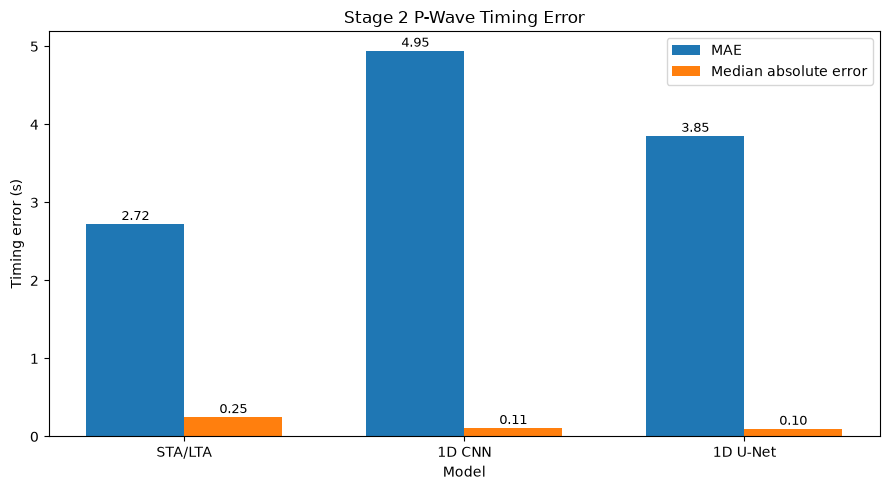

Saved: ../results/figures/stage2_timing_error_comparison.png


In [8]:
plt.figure(figsize=(9, 5))

x = list(range(len(stage2_results)))
width = 0.35

mae_bars = plt.bar(
    [value - width / 2 for value in x],
    stage2_results["MAE_s"],
    width=width,
    label="MAE"
)

median_bars = plt.bar(
    [value + width / 2 for value in x],
    stage2_results["Median_error_s"],
    width=width,
    label="Median absolute error"
)

plt.xticks(
    x,
    stage2_results["Model"]
)

plt.ylabel("Timing error (s)")
plt.xlabel("Model")
plt.title("Stage 2 P-Wave Timing Error")
plt.legend()

for bars in [mae_bars, median_bars]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.05,
            f"{value:.2f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()

stage2_error_path = figures_dir / "stage2_timing_error_comparison.png"
plt.savefig(stage2_error_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {stage2_error_path}")


## Stage 2 model interpretation

STA/LTA achieves the lowest mean absolute timing error, while the machine-learning pickers provide stronger tolerance-based accuracy.

The 1D CNN has the highest proportion of picks within ±0.5 seconds. The 1D U-Net achieves the lowest median error and the highest proportion of picks within ±2 seconds.

The results indicate that the methods have different error characteristics rather than one method being uniformly superior across all metrics.


## Final project conclusions

Stage 1 demonstrates that machine-learning methods improve earthquake-versus-noise classification over the evaluated STA/LTA baseline. Random Forest achieves the highest F1 score, while the 1D CNN provides high recall.

Stage 2 demonstrates that both CNN-based approaches can localize P-wave arrivals with high typical timing accuracy. The U-Net reduces the mean absolute error relative to the baseline CNN while retaining strong tolerance-based accuracy.

The final system combines traditional signal processing with machine-learning approaches for earthquake detection and P-wave arrival-time estimation.


## Generated result files

The final analysis produces:

- `results/figures/stage1_f1_comparison.png`
- `results/figures/stage2_tolerance_comparison.png`
- `results/figures/stage2_timing_error_comparison.png`
